In [2]:
from google.colab import drive
drive.mount('/content/drive')
REQUIREMENT_PATH ="/content/drive/MyDrive/Emotion_Detection_in sinhala_language_text_in_Social_Media/requirements.txt"

Mounted at /content/drive


In [4]:
#load dataset
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Emotion_Detection_in sinhala_language_text_in_Social_Media/data/labeled_dataset_final(in).csv")

print(df.head())


                                                text    label
0  තමන්ගේ සීමාව දන ගෙන හැසිරෙන්න ඕන..ගෑනු දරුවෙක්...  disgust
1  කවදාවත් අනුමත කරන්න බැරි දෙයක් .අපි ඔබ සමගයි. ...  sadness
2        ඔහුගේ අසනීපය නිසා මුලු නිවසෙමසතුට නැතිවෙලා.  sadness
3               අලියොන්ට අහුවුනොත් පාගලා මරලා දානවා.     fear
4                              මේවට දඩුවම් දෙන්න ඕනේ    anger


In [5]:
#train-test spilt
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

In [6]:
#TF-IDF Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# **Naive Bayes**

In [7]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)

pred_nb = nb.predict(X_test_tfidf)

acc_nb = accuracy_score(y_test, pred_nb)

print("Naive Bayes Accuracy:", acc_nb)

Naive Bayes Accuracy: 0.5897009966777409


# **Logistic Regression**

In [8]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_tfidf, y_train)

pred_lr = lr.predict(X_test_tfidf)

acc_lr = accuracy_score(y_test, pred_lr)

print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 0.6029900332225914


# **SVM**

In [9]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train_tfidf, y_train)

pred_svm = svm.predict(X_test_tfidf)

acc_svm = accuracy_score(y_test, pred_svm)

print("SVM Accuracy:", acc_svm)

SVM Accuracy: 0.6079734219269103


# **Random Forest**

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_tfidf, y_train)

pred_rf = rf.predict(X_test_tfidf)

acc_rf = accuracy_score(y_test, pred_rf)

print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.5764119601328903


In [11]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_svm))

              precision    recall  f1-score   support

       anger       0.55      0.57      0.56        98
     disgust       0.47      0.45      0.46       104
        fear       0.73      0.71      0.72        99
         joy       0.66      0.70      0.68       101
     sadness       0.54      0.50      0.52       101
    surprise       0.68      0.73      0.70        99

    accuracy                           0.61       602
   macro avg       0.61      0.61      0.61       602
weighted avg       0.61      0.61      0.61       602



In [12]:
results = pd.DataFrame({
    "Model":[
        "Naive Bayes",
        "Logistic Regression",
        "SVM",
        "Random Forest"
    ],
    "Accuracy":[
        acc_nb,
        acc_lr,
        acc_svm,
        acc_rf
    ]
})

print(results.sort_values("Accuracy", ascending=False))

                 Model  Accuracy
2                  SVM  0.607973
1  Logistic Regression  0.602990
0          Naive Bayes  0.589701
3        Random Forest  0.576412


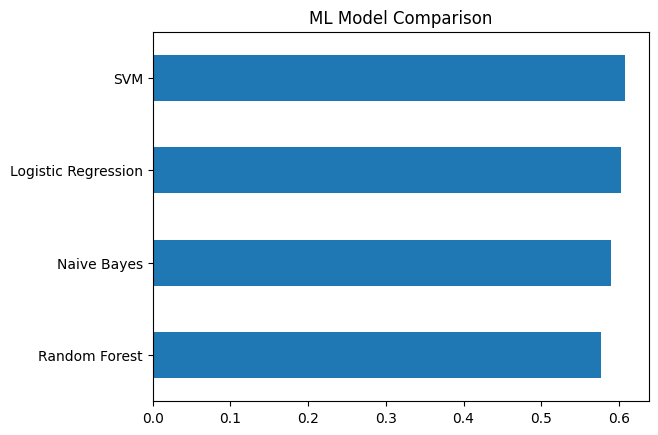

In [13]:
import matplotlib.pyplot as plt

results.sort_values("Accuracy").plot(
    x="Model",
    y="Accuracy",
    kind="barh",
    legend=False
)

plt.title("ML Model Comparison")
plt.ylabel("")
plt.show()